In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kapillondhe/american-sign-language")

print("Path to dataset files:", path)

100%|██████████| 4.64G/4.64G [01:01<00:00, 80.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kapillondhe/american-sign-language/versions/1


In [6]:
print(path)

/root/.cache/kagglehub/datasets/kapillondhe/american-sign-language/versions/1


In [8]:
train_path = "/root/.cache/kagglehub/datasets/kapillondhe/american-sign-language/versions/1/ASL_Dataset/Train"

test_path = "/root/.cache/kagglehub/datasets/kapillondhe/american-sign-language/versions/1/ASL_Dataset/Test"
print("Loading train")
X_train, y_train = load_images(train_path, max_per_class=1000)

print("Loading test")
X_test, y_test   = load_images(test_path, max_per_class=500)

print(f"\nTrain: {X_train.shape} | Labels: {y_train.shape}")
print(f"Test:  {X_test.shape}  | Labels: {y_test.shape}")

Loading train
Loading test

Train: (28000, 64, 64) | Labels: (28000,)
Test:  (112, 64, 64)  | Labels: (112,)


In [2]:
import os
import numpy as np
import cv2
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle
import matplotlib.pyplot as plt

In [3]:
def load_images(folder_path, img_size=64, max_per_class=100):
    images = []
    labels = []

    for class_name in sorted(os.listdir(folder_path)):
        class_path = os.path.join(folder_path, class_name)

        if not os.path.isdir(class_path):
            continue

        count = 0
        for img_name in os.listdir(class_path):
            if count >= max_per_class:
                break

            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            _, mask = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

            img = cv2.bitwise_and(img, img, mask=mask)

            img = cv2.resize(img, (img_size, img_size))
            img = img / 255.0

            images.append(img)
            labels.append(class_name)
            count += 1

    return np.array(images), np.array(labels)

In [9]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded  = le.transform(y_test)

print(f"Classes ({len(le.classes_)}): {le.classes_}")

Classes (28): ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'Nothing' 'O' 'P'
 'Q' 'R' 'S' 'Space' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']


In [10]:

X_train_ml = X_train.reshape(len(X_train), -1)
X_test_ml  = X_test.reshape(len(X_test), -1)


X_train_dl = X_train.reshape(-1, 64, 64, 1)
X_test_dl  = X_test.reshape(-1, 64, 64, 1)

print(f"ML shape → X_train: {X_train_ml.shape}")
print(f"DL shape → X_train: {X_train_dl.shape}")

ML shape → X_train: (28000, 4096)
DL shape → X_train: (28000, 64, 64, 1)


In [11]:
from sklearn.utils import shuffle

X_train, y_train_encoded = shuffle(X_train, y_train_encoded, random_state=42)

X_train_ml = X_train.reshape(len(X_train), -1)
X_train_dl = X_train.reshape(-1, 64, 64, 1)

y_train_ml = y_train_encoded
y_train_dl = y_train_encoded

print("Shuffle done")

Shuffle done


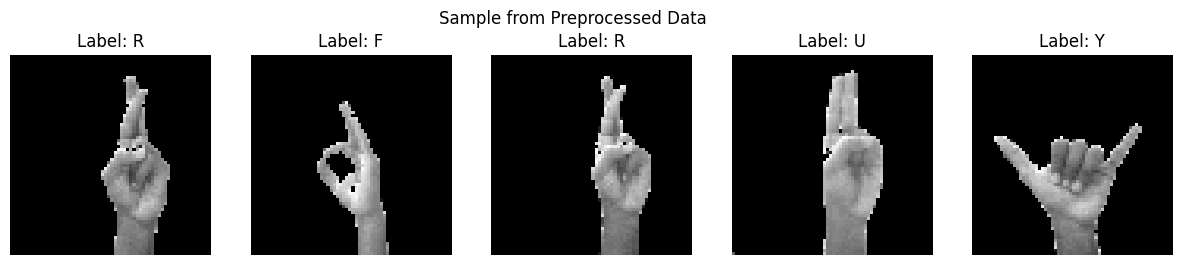

In [12]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i, ax in enumerate(axes):
    ax.imshow(X_train_dl[i].reshape(64, 64), cmap='gray')
    ax.set_title(f"Label: {le.classes_[y_train_dl[i]]}")
    ax.axis('off')

plt.suptitle("Sample from Preprocessed Data")
plt.show()

In [13]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report


svm_model = SVC(kernel='linear')


svm_model.fit(X_train_ml, y_train_encoded)


svm_pred = svm_model.predict(X_test_ml)


print("SVM Accuracy:",
      accuracy_score(y_test_encoded, svm_pred))


print(classification_report(y_test_encoded, svm_pred))

SVM Accuracy: 0.9196428571428571
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       0.44      1.00      0.62         4
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00         4
           4       1.00      1.00      1.00         4
           5       1.00      1.00      1.00         4
           6       1.00      1.00      1.00         4
           7       1.00      1.00      1.00         4
           8       1.00      1.00      1.00         4
           9       1.00      1.00      1.00         4
          10       0.80      1.00      0.89         4
          11       1.00      1.00      1.00         4
          12       0.67      1.00      0.80         4
          13       1.00      0.50      0.67         4
          14       1.00      1.00      1.00         4
          15       1.00      1.00      1.00         4
          16       1.00      1.00      1.00     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [14]:
from sklearn.neighbors import KNeighborsClassifier


knn_model = KNeighborsClassifier(n_neighbors=3)

knn_model.fit(X_train_ml, y_train_encoded)


knn_pred = knn_model.predict(X_test_ml)


print("KNN Accuracy:",
      accuracy_score(y_test_encoded, knn_pred))


print(classification_report(y_test_encoded, knn_pred))

KNN Accuracy: 0.9910714285714286
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00         4
           4       1.00      1.00      1.00         4
           5       1.00      1.00      1.00         4
           6       1.00      1.00      1.00         4
           7       1.00      1.00      1.00         4
           8       1.00      1.00      1.00         4
           9       1.00      1.00      1.00         4
          10       1.00      1.00      1.00         4
          11       1.00      1.00      1.00         4
          12       0.80      1.00      0.89         4
          13       1.00      0.75      0.86         4
          14       1.00      1.00      1.00         4
          15       1.00      1.00      1.00         4
          16       1.00      1.00      1.00     